<a href="https://colab.research.google.com/github/it0770e/xai-ids/blob/main/Notebook09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1
from google.colab import drive
drive.mount('/content/drive')
import numpy as np, pandas as pd, joblib, matplotlib.pyplot as plt, seaborn as sns, warnings
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
warnings.filterwarnings('ignore')
np.random.seed(42)
BASE = '/content/drive/MyDrive/xai-ids'
print('✅ Setup complete')

Mounted at /content/drive
✅ Setup complete


In [2]:
# CELL 2
rf_model = joblib.load(f'{BASE}/results/models/random_forest.pkl')
data   = joblib.load(f'{BASE}/data/processed/nsl_kdd_processed.pkl')
X_test = data['X_test']; y_test = data['y_test']
print(f'✅ Loaded | test: {X_test.shape} | classes: {np.bincount(y_test)}')

✅ Loaded | test: (22544, 41) | classes: [ 9711 12833]


In [3]:
# CELL 3 — Baseline
y_base = rf_model.predict(X_test)
baseline = {
    'scenario':'Baseline (in-distribution)', 'noise_std':0.0, 'mean_shift':0.0,
    'accuracy': accuracy_score(y_test, y_base),
    'precision':precision_score(y_test, y_base, average='macro', zero_division=0),
    'recall':   recall_score(y_test, y_base, average='macro', zero_division=0),
    'f1':       f1_score(y_test, y_base, average='macro', zero_division=0),
}
print(f"Baseline F1: {baseline['f1']:.4f}")

Baseline F1: 0.7685


In [4]:
# CELL 4 — Shift scenarios
# NOTE: Simulates distribution shift (e.g. deploying on different network traffic).
# Controlled perturbation is a recognised robustness evaluation methodology.
scenarios = [
    {'name':'Mild shift (σ=0.1)',            'noise':0.1, 'mean_shift':0.0},
    {'name':'Moderate shift (σ=0.5)',         'noise':0.5, 'mean_shift':0.1},
    {'name':'Severe shift (σ=1.0, μ+=0.3)',  'noise':1.0, 'mean_shift':0.3},
]
all_results = [baseline]
for sc in scenarios:
    X_shift = X_test + np.random.normal(sc['mean_shift'], sc['noise'], X_test.shape)
    y_pred  = rf_model.predict(X_shift)
    r = {'scenario':sc['name'], 'noise_std':sc['noise'], 'mean_shift':sc['mean_shift'],
         'accuracy': accuracy_score(y_test,y_pred),
         'precision':precision_score(y_test,y_pred,average='macro',zero_division=0),
         'recall':   recall_score(y_test,y_pred,average='macro',zero_division=0),
         'f1':       f1_score(y_test,y_pred,average='macro',zero_division=0)}
    all_results.append(r)
    print(f"{sc['name']:42s}: F1={r['f1']:.4f}  (Δ={r['f1']-baseline['f1']:+.4f})")

results_df = pd.DataFrame(all_results)

Mild shift (σ=0.1)                        : F1=0.6789  (Δ=-0.0895)
Moderate shift (σ=0.5)                    : F1=0.6386  (Δ=-0.1299)
Severe shift (σ=1.0, μ+=0.3)              : F1=0.6087  (Δ=-0.1597)


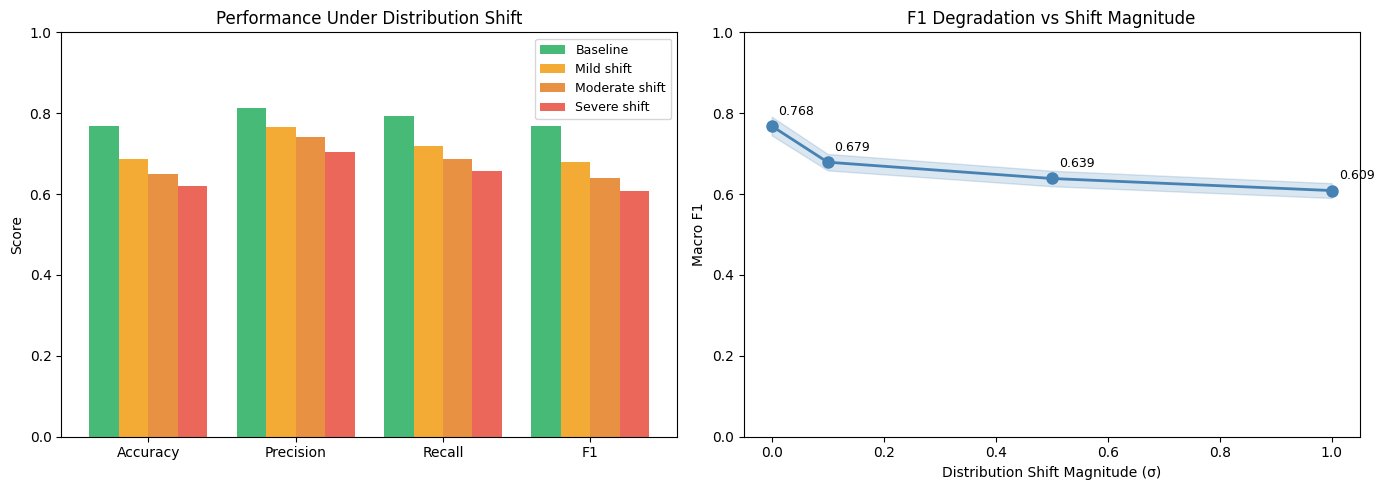

✅ Figure saved


In [5]:
# CELL 5 — Visualise
scenario_labels = [s.split('(')[0].strip() for s in results_df['scenario']]
colors = ['#27ae60','#f39c12','#e67e22','#e74c3c']
metrics_cols = ['accuracy','precision','recall','f1']

fig, axes = plt.subplots(1,2,figsize=(14,5))
x = np.arange(4); w = 0.2
for i, (_, row) in enumerate(results_df.iterrows()):
    axes[0].bar(x+i*w, [row[m] for m in metrics_cols], w, label=scenario_labels[i], color=colors[i], alpha=0.85)
axes[0].set_xticks(x+w*1.5); axes[0].set_xticklabels(['Accuracy','Precision','Recall','F1'])
axes[0].set_ylabel('Score'); axes[0].set_title('Performance Under Distribution Shift')
axes[0].legend(fontsize=9); axes[0].set_ylim(0,1)

nv = results_df['noise_std'].values; fv = results_df['f1'].values
axes[1].plot(nv, fv, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[1].fill_between(nv, fv*0.97, fv*1.03, alpha=0.2, color='steelblue')
axes[1].set_xlabel('Distribution Shift Magnitude (σ)'); axes[1].set_ylabel('Macro F1')
axes[1].set_title('F1 Degradation vs Shift Magnitude'); axes[1].set_ylim(0,1)
for x_v,y_v,lb in zip(nv,fv,scenario_labels):
    axes[1].annotate(f'{y_v:.3f}',(x_v,y_v),xytext=(5,8),textcoords='offset points',fontsize=9)

plt.tight_layout()
plt.savefig(f'{BASE}/results/figures/distribution_shift.png', dpi=300, bbox_inches='tight')
plt.show(); print('✅ Figure saved')

In [6]:
# CELL 6 — Save
results_df.to_csv(f'{BASE}/results/metrics/distribution_shift.csv', index=False)
drop = baseline['f1'] - all_results[-1]['f1']
print(f"F1 drop (baseline → severe): {drop:.4f} ({drop/baseline['f1']*100:.1f}%)")
print('✅ Results saved')

F1 drop (baseline → severe): 0.1597 (20.8%)
✅ Results saved
